# Step 2b — DANN Improved

**What changed vs 01_dann_training.ipynb:**

| Issue (from run 1) | Fix |
|---|---|
| Domain acc climbed to 71% (encoder not aligning) | `domain_loss_weight` 0.1 → **0.3** |
| Source class loss crashed to 0.009 (overfit) | Label smoothing + stronger dropout |
| Exhausted F1=0.085, Th1-like F1=0.189 | Class weights on CE loss |
| Adversarial training unstable | Label smoothing on domain labels (0.9/0.1) + gradient clipping |

Best val_class_loss in run 1 was epoch 5 (0.376). Goal: hold that longer and push target F1 above 0.39.

In [2]:
import os, json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

tf.random.set_seed(42)
np.random.seed(42)

PROJECT_ROOT = Path.cwd().parent.parent if Path.cwd().name == 'step2_dann' else Path.cwd()
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)
print('Project root:', PROJECT_ROOT)
print('TF:', tf.__version__)

Project root: /Users/kirtan/Projects /NNDL
TF: 2.21.0


## 1. Data Loading + CORAL + Class Weights

In [3]:
X_train_src = np.load(PROJECT_ROOT / 'step3_X_train.npy').astype(np.float32)
y_train_src = np.load(PROJECT_ROOT / 'step3_y_train.npy').astype(np.int64)
X_test_src  = np.load(PROJECT_ROOT / 'step3_X_test.npy').astype(np.float32)
y_test_src  = np.load(PROJECT_ROOT / 'step3_y_test.npy').astype(np.int64)
X_target_raw = np.load(PROJECT_ROOT / 'gse126030_preprocessed.npy').astype(np.float32)

with open(PROJECT_ROOT / 'step3_label_mapping.json') as f:
    label_map = json.load(f)
class_names = [label_map[str(i)] for i in range(len(label_map))]
n_classes = len(class_names)

labels_csv = PROJECT_ROOT / 'improvements/1_label_validation/label_validation_output/gse126030_reclustered_labels.csv'
df_labels = pd.read_csv(labels_csv)
mask = (df_labels['confidence'] >= 0.55) & (df_labels['new_class'] != 'Uncertain')
X_target_eval_raw = X_target_raw[mask.values]
y_target_eval = np.array([class_names.index(n) for n in df_labels.loc[mask, 'new_class']], dtype=np.int64)

# Class weights — upweight minority classes (Exhausted x1.71, Th1-like x2.02)
classes, counts = np.unique(y_train_src, return_counts=True)
total = len(y_train_src)
class_weight = {int(c): total / (n_classes * cnt) for c, cnt in zip(classes, counts)}
print('Class weights:', {class_names[k]: round(v, 3) for k, v in class_weight.items()})
print(f'Source train: {X_train_src.shape}  Target: {X_target_raw.shape}  Target eval: {X_target_eval_raw.shape}')

Class weights: {'Effector': np.float64(0.591), 'Exhausted': np.float64(1.71), 'Naive': np.float64(1.267), 'Other_CD4': np.float64(0.886), 'Th1-like': np.float64(2.017), 'Treg': np.float64(0.764)}
Source train: (6824, 3000)  Target: (63877, 3000)  Target eval: (12776, 3000)


In [4]:
def coral_align(X_src, X_tgt, reg=1e-3):
    src_mean = X_src.mean(axis=0)
    tgt_mean = X_tgt.mean(axis=0)
    Xs = X_src - src_mean
    Xt = X_tgt - tgt_mean
    Cs = (Xs.T @ Xs) / (Xs.shape[0] - 1) + reg * np.eye(Xs.shape[1])
    Ct = (Xt.T @ Xt) / (Xt.shape[0] - 1) + reg * np.eye(Xt.shape[1])

    def mat_sqrt(M):
        vals, vecs = np.linalg.eigh(M)
        return vecs @ np.diag(np.sqrt(np.maximum(vals, 0))) @ vecs.T

    def mat_inv_sqrt(M):
        vals, vecs = np.linalg.eigh(M)
        return vecs @ np.diag(1.0 / np.sqrt(np.maximum(vals, 1e-10))) @ vecs.T

    W = mat_inv_sqrt(Ct) @ mat_sqrt(Cs)
    return ((Xt @ W) + src_mean).astype(np.float32)

print('Running CORAL alignment...')
X_target_coral = coral_align(X_train_src, X_target_raw)
X_target_eval  = X_target_coral[mask.values]
print('Done.')

Running CORAL alignment...
Done.


## 2. Model — GRL + DANN with Class Weights & Label Smoothing

In [5]:
class GradientReversalLayer(keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.lambda_val = tf.Variable(0.0, trainable=False, dtype=tf.float32)

    def call(self, x):
        lam = self.lambda_val
        @tf.custom_gradient
        def _reverse(x):
            return x, lambda dy: -lam * dy
        return _reverse(x)


def build_encoder(input_dim):
    inp = keras.Input(shape=(input_dim,))
    x = layers.Dense(512, activation='relu')(inp)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.4)(x)          # increased from 0.3
    x = layers.Dense(256, activation='relu')(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(0.3)(x)          # increased from 0.2
    x = layers.Dense(128, activation='relu')(x)
    return keras.Model(inp, x, name='encoder')


def build_label_predictor(latent_dim, n_classes):
    inp = keras.Input(shape=(latent_dim,))
    x = layers.Dense(64, activation='relu')(inp)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    return keras.Model(inp, out, name='label_predictor')


def build_domain_discriminator(latent_dim):
    # Deeper discriminator — harder to fool, stronger alignment signal
    inp = keras.Input(shape=(latent_dim,))
    x = layers.Dense(128, activation='relu')(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inp, out, name='domain_discriminator')


print('Components defined.')

Components defined.


In [6]:
class DANNModel(keras.Model):
    def __init__(self, encoder, label_predictor, domain_discriminator, grl,
                 domain_loss_weight=0.3, class_weight=None, label_smoothing=0.1, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.label_predictor = label_predictor
        self.domain_discriminator = domain_discriminator
        self.grl = grl
        self.domain_loss_weight = domain_loss_weight
        self.label_smoothing = label_smoothing

        # Convert class_weight dict to a lookup tensor
        if class_weight is not None:
            n = max(class_weight.keys()) + 1
            cw = np.array([class_weight[i] for i in range(n)], dtype=np.float32)
            self.class_weight_tensor = tf.constant(cw)
        else:
            self.class_weight_tensor = None

        self.total_loss_tracker  = keras.metrics.Mean(name='loss')
        self.class_loss_tracker  = keras.metrics.Mean(name='class_loss')
        self.domain_loss_tracker = keras.metrics.Mean(name='domain_loss')
        self.class_acc_tracker   = keras.metrics.SparseCategoricalAccuracy(name='class_acc')
        self.domain_acc_tracker  = keras.metrics.BinaryAccuracy(name='domain_acc')

    def call(self, inputs, training=False):
        z = self.encoder(inputs, training=training)
        return self.label_predictor(z, training=training)

    def train_step(self, data):
        (src_x, src_y), (tgt_x,) = data
        batch = tf.shape(src_x)[0]

        # Label smoothing on domain labels (0.9 / 0.1 instead of 1 / 0)
        smooth = self.label_smoothing
        d_src = tf.fill((batch, 1), smooth)                    # source = 0 + smooth
        d_tgt = tf.fill((batch, 1), 1.0 - smooth)             # target = 1 - smooth

        with tf.GradientTape() as tape:
            z_src = self.encoder(src_x, training=True)
            z_tgt = self.encoder(tgt_x, training=True)

            # Classification loss with per-sample class weights
            y_pred = self.label_predictor(z_src, training=True)
            per_sample_loss = keras.losses.sparse_categorical_crossentropy(src_y, y_pred)
            if self.class_weight_tensor is not None:
                sample_weights = tf.gather(self.class_weight_tensor, src_y)
                class_loss = tf.reduce_mean(per_sample_loss * sample_weights)
            else:
                class_loss = tf.reduce_mean(per_sample_loss)

            # Domain adversarial loss (both domains through GRL)
            z_src_rev = self.grl(z_src)
            z_tgt_rev = self.grl(z_tgt)
            d_pred_src = self.domain_discriminator(z_src_rev, training=True)
            d_pred_tgt = self.domain_discriminator(z_tgt_rev, training=True)
            domain_loss = (
                tf.reduce_mean(keras.losses.binary_crossentropy(d_src, d_pred_src)) +
                tf.reduce_mean(keras.losses.binary_crossentropy(d_tgt, d_pred_tgt))
            )

            total_loss = class_loss + self.domain_loss_weight * domain_loss

        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        d_both = tf.concat([d_src, d_tgt], axis=0)
        d_pred = tf.concat([d_pred_src, d_pred_tgt], axis=0)

        self.total_loss_tracker.update_state(total_loss)
        self.class_loss_tracker.update_state(class_loss)
        self.domain_loss_tracker.update_state(domain_loss)
        self.class_acc_tracker.update_state(src_y, y_pred)
        self.domain_acc_tracker.update_state(d_both, d_pred)

        return {
            'loss': self.total_loss_tracker.result(),
            'class_loss': self.class_loss_tracker.result(),
            'domain_loss': self.domain_loss_tracker.result(),
            'class_acc': self.class_acc_tracker.result(),
            'domain_acc': self.domain_acc_tracker.result(),
        }

    def test_step(self, data):
        x, y = data
        z = self.encoder(x, training=False)
        y_pred = self.label_predictor(z, training=False)
        loss = tf.reduce_mean(keras.losses.sparse_categorical_crossentropy(y, y_pred))
        self.class_loss_tracker.update_state(loss)
        self.class_acc_tracker.update_state(y, y_pred)
        return {'class_loss': self.class_loss_tracker.result(), 'class_acc': self.class_acc_tracker.result()}

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.class_loss_tracker,
                self.domain_loss_tracker, self.class_acc_tracker, self.domain_acc_tracker]

print('DANNModel defined.')

DANNModel defined.


## 3. Instantiate + Datasets

In [7]:
BATCH_SIZE         = 128
LEARNING_RATE      = 2e-4
DOMAIN_LOSS_WEIGHT = 0.3   # was 0.1
MAX_EPOCHS         = 100
PATIENCE           = 15
LABEL_SMOOTHING    = 0.1   # domain label smoothing

grl             = GradientReversalLayer(name='grl')
encoder         = build_encoder(X_train_src.shape[1])
label_predictor = build_label_predictor(128, n_classes)
domain_disc     = build_domain_discriminator(128)

dann = DANNModel(
    encoder=encoder,
    label_predictor=label_predictor,
    domain_discriminator=domain_disc,
    grl=grl,
    domain_loss_weight=DOMAIN_LOSS_WEIGHT,
    class_weight=class_weight,
    label_smoothing=LABEL_SMOOTHING,
    name='dann_v2'
)
dann.compile(
    optimizer=keras.optimizers.Adam(LEARNING_RATE, clipnorm=1.0)  # gradient clipping
)

src_ds = (
    tf.data.Dataset.from_tensor_slices((X_train_src, y_train_src))
    .shuffle(10000, seed=42)
    .batch(BATCH_SIZE, drop_remainder=True)
)
tgt_ds = (
    tf.data.Dataset.from_tensor_slices((X_target_coral,))
    .shuffle(100000, seed=42)
    .batch(BATCH_SIZE, drop_remainder=True)
    .repeat()
)
train_ds = tf.data.Dataset.zip((src_ds, tgt_ds))
val_ds   = tf.data.Dataset.from_tensor_slices((X_test_src, y_test_src)).batch(BATCH_SIZE)

encoder.summary()
print(f'Steps/epoch: {len(src_ds)}')

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,536,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 512)            │         1,024 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 256)            │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,702,272 (6.49 MB)

 Trainable params: 1,702,272 (6.49 MB)

 Non-trainable params: 0 (0.00 B)

Steps/epoch: 53


## 4. Lambda Scheduler + Callbacks

In [8]:
class DANNLambdaScheduler(keras.callbacks.Callback):
    def __init__(self, grl_layer, total_epochs):
        super().__init__()
        self.grl = grl_layer
        self.total_epochs = total_epochs

    def on_epoch_begin(self, epoch, logs=None):
        p = epoch / self.total_epochs
        lam = 2.0 / (1.0 + np.exp(-10.0 * p)) - 1.0
        self.grl.lambda_val.assign(lam)

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 5 == 0:
            lam = float(self.grl.lambda_val.numpy())
            print(f'  [λ={lam:.3f}]', end='')


callbacks = [
    DANNLambdaScheduler(grl, MAX_EPOCHS),
    keras.callbacks.EarlyStopping(
        monitor='val_class_loss', mode='min',
        patience=PATIENCE, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_class_loss', mode='min',
        factor=0.5, patience=7, min_lr=1e-6, verbose=1
    ),
]
print('Callbacks ready.')

Callbacks ready.


## 5. Training

In [9]:
history = dann.fit(
    train_ds,
    epochs=MAX_EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - class_acc: 0.3903 - class_loss: 1.5801 - domain_acc: 0.0000e+00 - domain_loss: 1.4799 - loss: 2.0241 - val_class_acc: 0.6600 - val_class_loss: 0.9333 - learning_rate: 2.0000e-04
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - class_acc: 0.6846 - class_loss: 0.8555 - domain_acc: 0.0000e+00 - domain_loss: 1.4218 - loss: 1.2820 - val_class_acc: 0.7825 - val_class_loss: 0.5909 - learning_rate: 2.0000e-04
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - class_acc: 0.8100 - class_loss: 0.5316 - domain_acc: 0.0000e+00 - domain_loss: 1.4041 - loss: 0.9528 - val_class_acc: 0.8277 - val_class_loss: 0.4725 - learning_rate: 2.0000e-04
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - class_acc: 0.8750 - class_loss: 0.3469 - domain_acc: 0.0000e+00 - domain_loss: 1.3911 - loss: 0.7642 - val_class_acc: 0.8605 - val_class_loss: 0.4033 - learning_rate: 2.0000e-04
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - class_acc: 0.9220 - 

## 6. Training Curves

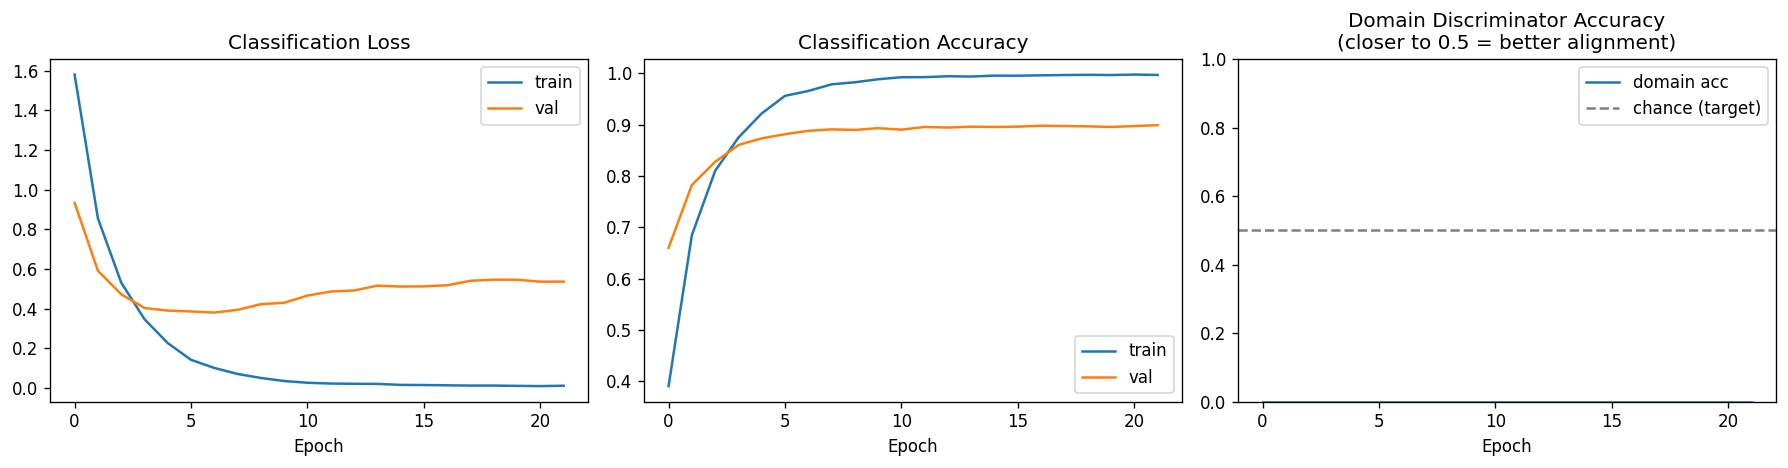

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history.history['class_loss'], label='train')
axes[0].plot(history.history['val_class_loss'], label='val')
axes[0].set_title('Classification Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['class_acc'], label='train')
axes[1].plot(history.history['val_class_acc'], label='val')
axes[1].set_title('Classification Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history.history['domain_acc'], label='domain acc')
axes[2].axhline(0.5, color='gray', linestyle='--', label='chance (target)')
axes[2].set_title('Domain Discriminator Accuracy\n(closer to 0.5 = better alignment)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylim(0, 1)
axes[2].legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves_v2.png', bbox_inches='tight')
plt.show()

## 7. Evaluation — Source Test

In [11]:
y_pred_src = np.argmax(dann.predict(X_test_src, batch_size=BATCH_SIZE), axis=1)
src_f1 = f1_score(y_test_src, y_pred_src, average='macro')
print(f'Source Test Macro F1: {src_f1:.4f}')
print(classification_report(y_test_src, y_pred_src, target_names=class_names))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Source Test Macro F1: 0.8751
              precision    recall  f1-score   support

    Effector       0.92      0.95      0.93       482
   Exhausted       0.90      0.95      0.93       166
       Naive       0.78      0.86      0.82       224
   Other_CD4       0.83      0.79      0.81       321
    Th1-like       0.85      0.78      0.81       141
        Treg       0.96      0.93      0.95       372

    accuracy                           0.89      1706
   macro avg       0.88      0.88      0.88      1706
weighted avg       0.89      0.89      0.89      1706



## 8. Evaluation — Target Domain

In [12]:
y_pred_tgt_probs = dann.predict(X_target_eval, batch_size=BATCH_SIZE)
y_pred_tgt = np.argmax(y_pred_tgt_probs, axis=1)

tgt_f1 = f1_score(y_target_eval, y_pred_tgt, average='macro')
print(f'Target Macro F1: {tgt_f1:.4f}')
print(classification_report(y_target_eval, y_pred_tgt, target_names=class_names))

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Target Macro F1: 0.3946
              precision    recall  f1-score   support

    Effector       0.58      0.55      0.56      2839
   Exhausted       0.07      0.11      0.09       903
       Naive       0.83      0.52      0.64      3806
   Other_CD4       0.36      0.34      0.35      2127
    Th1-like       0.18      0.21      0.19      1031
        Treg       0.45      0.67      0.54      2070

    accuracy                           0.47     12776
   macro avg       0.41      0.40      0.39     12776
weighted avg       0.53      0.47      0.48     12776



## 9. Confusion Matrices

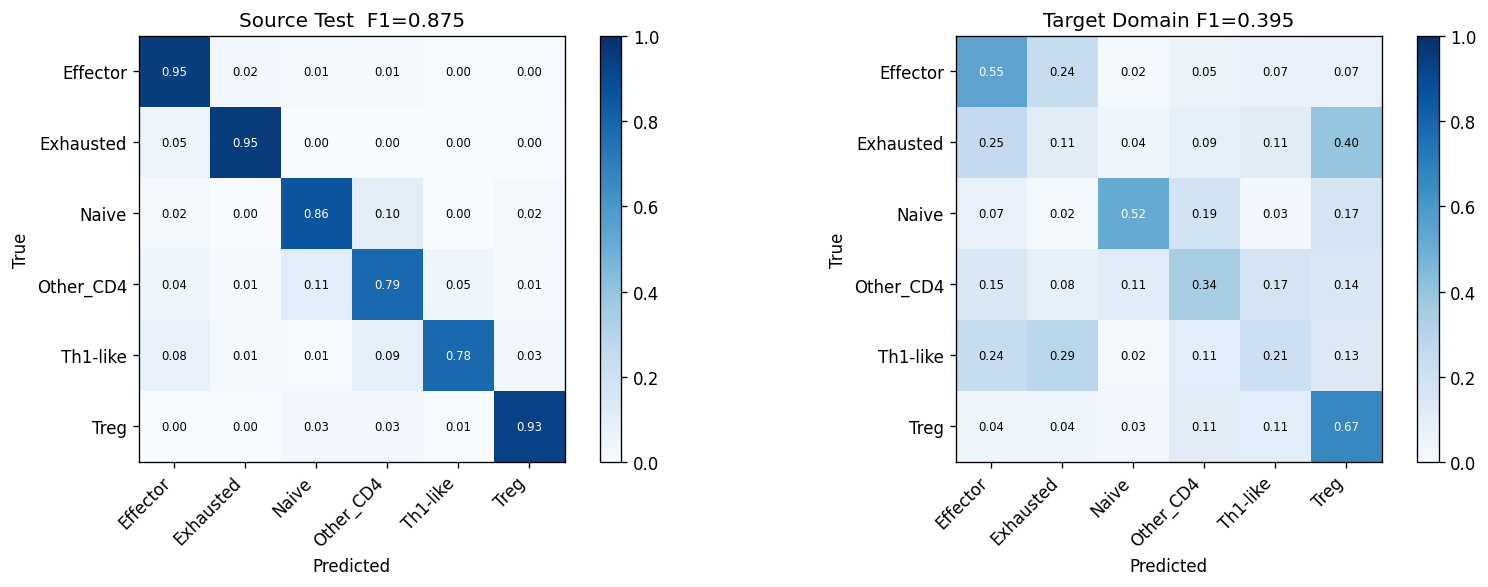

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_true, y_pred, title in [
    (axes[0], y_test_src,    y_pred_src, f'Source Test  F1={src_f1:.3f}'),
    (axes[1], y_target_eval, y_pred_tgt, f'Target Domain F1={tgt_f1:.3f}'),
]:
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xticks(range(n_classes)); ax.set_yticks(range(n_classes))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center',
                    color='white' if cm[i,j] > 0.5 else 'black', fontsize=7)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices_v2.png', bbox_inches='tight')
plt.show()

## 10. Compare v1 vs v2 + Save

In [14]:
from sklearn.metrics import accuracy_score

# Load v1 for comparison
v1 = json.load(open(RESULTS_DIR / 'dann_results.json'))

print('=== DANN v1 vs v2 ===')
print(f'{"":20s} {"v1":>10s} {"v2":>10s} {"delta":>10s}')
print('-' * 52)
for label, v1_val, v2_val in [
    ('Source F1',  v1['source_test']['macro_f1'],  src_f1),
    ('Source Acc', v1['source_test']['accuracy'],  accuracy_score(y_test_src, y_pred_src)),
    ('Target F1',  v1['target_eval']['macro_f1'],  tgt_f1),
    ('Target Acc', v1['target_eval']['accuracy'],  accuracy_score(y_target_eval, y_pred_tgt)),
]:
    delta = v2_val - v1_val
    sign = '+' if delta >= 0 else ''
    print(f'{label:20s} {v1_val:10.4f} {v2_val:10.4f} {sign}{delta:9.4f}')

src_report = classification_report(y_test_src,    y_pred_src, target_names=class_names, output_dict=True)
tgt_report = classification_report(y_target_eval, y_pred_tgt, target_names=class_names, output_dict=True)

results_v2 = {
    'model': 'DANN_v2',
    'config': {
        'domain_loss_weight': DOMAIN_LOSS_WEIGHT,
        'label_smoothing': LABEL_SMOOTHING,
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'epochs_trained': len(history.history['loss']),
        'coral_aligned': True,
        'class_weighted': True,
        'gradient_clipping': True,
    },
    'source_test': {
        'macro_f1': src_f1,
        'accuracy': accuracy_score(y_test_src, y_pred_src),
        'per_class_f1': {cls: src_report[cls]['f1-score'] for cls in class_names},
    },
    'target_eval': {
        'macro_f1': tgt_f1,
        'accuracy': accuracy_score(y_target_eval, y_pred_tgt),
        'per_class_f1': {cls: tgt_report[cls]['f1-score'] for cls in class_names},
        'n_eval_cells': int(y_target_eval.shape[0]),
    },
}

with open(RESULTS_DIR / 'dann_results_v2.json', 'w') as f:
    json.dump(results_v2, f, indent=2)

dann.encoder.save(str(RESULTS_DIR / 'dann_v2_encoder.keras'))
dann.label_predictor.save(str(RESULTS_DIR / 'dann_v2_label_predictor.keras'))
print('\nSaved.')

=== DANN v1 vs v2 ===
                             v1         v2      delta
----------------------------------------------------
Source F1                0.8516     0.8751 +   0.0235
Source Acc               0.8687     0.8880 +   0.0193
Target F1                0.3910     0.3946 +   0.0036
Target Acc               0.4657     0.4655   -0.0002

Saved.
